In [1]:
import subprocess
subprocess.run(["pip", "install", "xgboost"])
subprocess.run(["pip", "install", "imbalanced-learn"])
print("Done — now restart the kernel and run all cells again")

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Done — now restart the kernel and run all cells again


In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier
from imblearn.combine import SMOTETomek
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, precision_score,
                             recall_score, f1_score)

In [3]:
# Load the engineered dataset
df_model = pd.read_csv("/home/ae7ba225-76ef-4005-aee2-7847a70630ed/SilentTelecomChurn/engineered_features.csv")
df_model.head()

,Tenure Group,Charge Level,Multiple Lines,Tech Support,Internet Service,Online Security,Contract,Churn
0,0,0,0,0,1,0,0,0
1,1,1,0,0,1,1,1,0
2,0,1,0,0,1,1,0,1
3,2,1,0,1,1,1,1,0
4,0,2,0,0,2,0,0,1


In [4]:
# Split features and target
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

print("Features:", X.columns.tolist())
print("Shape:", X.shape)

Features: ['Tenure Group', 'Charge Level', 'Multiple Lines', 'Tech Support', 'Internet Service', 'Online Security', 'Contract']
Shape: (7032, 7)


In [5]:
# Check class balance before SMOTETomek
print("Class distribution before SMOTETomek:")
print(y.value_counts())

Class distribution before SMOTETomek:
Churn
0    5163
1    1869
Name: count, dtype: int64


In [6]:
# Train test split — 70% train, 30% test
# Changed from 80/20 to 70/30 as advised by supervisor
# More test data means a more rigorous evaluation of model performance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 4922
Test samples: 2110


In [7]:
# Apply SMOTETomek to balance the training data
# SMOTETomek is a modernised version of SMOTE — it not only generates synthetic
# churn examples to balance the classes but also removes noisy borderline examples
# that could confuse the model, giving a cleaner and better balanced training set

smotetomek = SMOTETomek(random_state=42)
X_train_balanced, y_train_balanced = smotetomek.fit_resample(X_train, y_train)

print("Class distribution after SMOTETomek:")
print(pd.Series(y_train_balanced).value_counts())

Class distribution after SMOTETomek:
Churn
1    3614
0    3614
Name: count, dtype: int64


In [8]:
# Define the three individual base models
# These will be used both individually and in combinations

# Logistic Regression — Neslin et al. (2006)
lr_model = LogisticRegression(random_state=42)

# SVM — Coussement and Van den Poel (2008)
svm_model = SVC(probability=True, random_state=42)

# XGBoost — Chen and Guestrin (2016)
xgb_model = XGBClassifier(random_state=42, eval_metric="logloss")

In [9]:
# Train individual models first for comparison
lr_model.fit(X_train_balanced, y_train_balanced)
svm_model.fit(X_train_balanced, y_train_balanced)
xgb_model.fit(X_train_balanced, y_train_balanced)

print("All three individual models trained successfully")

All three individual models trained successfully


In [10]:
# Individual Model Results — Logistic Regression
lr_predictions = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]

print("=== Individual — Logistic Regression ===")
print(classification_report(y_test, lr_predictions, target_names=["No Churn", "Churn"]))

=== Individual — Logistic Regression ===
              precision    recall  f1-score   support

    No Churn       0.90      0.71      0.79      1549
       Churn       0.49      0.78      0.60       561

    accuracy                           0.73      2110
   macro avg       0.70      0.74      0.70      2110
weighted avg       0.79      0.73      0.74      2110



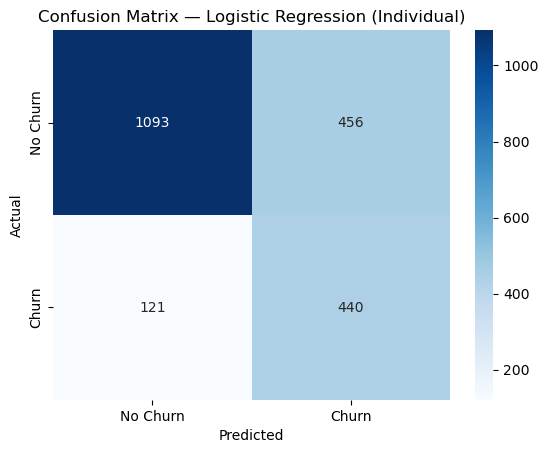

In [11]:
# Confusion Matrix — Individual Logistic Regression
cm_lr = confusion_matrix(y_test, lr_predictions)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix — Logistic Regression (Individual)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [12]:
# Metrics — Individual Logistic Regression
# Justification from Literature:
# Mettle et al. (2026) used Logistic Regression as one of three base learners
# in a soft-voting ensemble for telecom churn prediction, confirming its strength
# as an interpretable baseline model that competes with more complex algorithms.
# Source: Mettle et al. (2026). Enhancing Telecom Customer Churn Prediction Through
# Hyperparameter Tuning and Soft-Voting Ensemble Modeling.
# Applied Computational Intelligence and Soft Computing. https://doi.org/10.1155/acis/7620084

print("=== Logistic Regression Metrics ===")
print("Precision :", round(precision_score(y_test, lr_predictions), 2))
print("Recall    :", round(recall_score(y_test, lr_predictions), 2))
print("F1 Score  :", round(f1_score(y_test, lr_predictions), 2))
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_proba)
lr_auc = round(auc(lr_fpr, lr_tpr), 2)
print("AUC       :", lr_auc)

=== Logistic Regression Metrics ===
Precision : 0.49
Recall    : 0.78
F1 Score  : 0.6
AUC       : 0.82


In [13]:
# Individual Model Results — Support Vector Machine (SVM)
# Justification from Literature:
# An Integrated AI-Driven Framework for Customer Churn Prediction and Behavioural
# Analytics in Telecommunications (2026) used SVM alongside Logistic Regression
# for telecom churn prediction, confirming SVM as a strong classifier for this problem.
# Source: Nature Journal of Emerging Sciences Technologies and Innovations, 7(4), 337-347.
# https://doi.org/10.65752/n4ch1084
svm_predictions = svm_model.predict(X_test)
svm_proba = svm_model.predict_proba(X_test)[:, 1]

print("=== Individual — SVM ===")
print(classification_report(y_test, svm_predictions, target_names=["No Churn", "Churn"]))

=== Individual — SVM ===
              precision    recall  f1-score   support

    No Churn       0.89      0.73      0.80      1549
       Churn       0.50      0.76      0.60       561

    accuracy                           0.74      2110
   macro avg       0.70      0.74      0.70      2110
weighted avg       0.79      0.74      0.75      2110



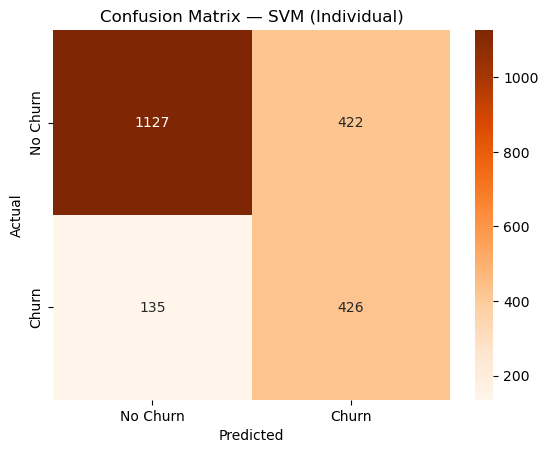

In [14]:
# Confusion Matrix — Individual SVM
cm_svm = confusion_matrix(y_test, svm_predictions)
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix — SVM (Individual)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [15]:
# Metrics — Individual SVM
print("=== SVM Metrics ===")
print("Precision :", round(precision_score(y_test, svm_predictions), 2))
print("Recall    :", round(recall_score(y_test, svm_predictions), 2))
print("F1 Score  :", round(f1_score(y_test, svm_predictions), 2))
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_proba)
svm_auc = round(auc(svm_fpr, svm_tpr), 2)
print("AUC       :", svm_auc)

=== SVM Metrics ===
Precision : 0.5
Recall    : 0.76
F1 Score  : 0.6
AUC       : 0.77


In [16]:
# Individual Model Results — XGBoost
# Model 3 — XGBoost
# Justification from Literature:
# Javed et al. (2026) specifically stated that XGBoost has become a widely used
# model for churn prediction because it is efficient and can be regularised,
# and several studies have shown it is more effective than baseline classifiers.
# Source: Javed, D., Jhanjhi, N.Z. and Ali, N.I. (2026). Explainable AI-Driven
# Triple Adaptive Feature Selection Model for Enhanced Telecom Churn Prediction.
# Results in Engineering, 111361.

xgb_predictions = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

print("=== Individual — XGBoost ===")
print(classification_report(y_test, xgb_predictions, target_names=["No Churn", "Churn"]))

=== Individual — XGBoost ===
              precision    recall  f1-score   support

    No Churn       0.89      0.73      0.80      1549
       Churn       0.50      0.75      0.60       561

    accuracy                           0.73      2110
   macro avg       0.69      0.74      0.70      2110
weighted avg       0.79      0.73      0.75      2110



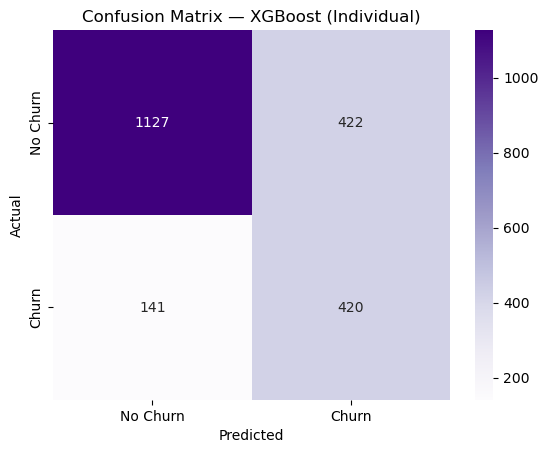

In [17]:
# Confusion Matrix — Individual XGBoost
cm_xgb = confusion_matrix(y_test, xgb_predictions)
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Purples",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix — XGBoost (Individual)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
# Metrics — Individual XGBoost
print("=== XGBoost Metrics ===")
print("Precision :", round(precision_score(y_test, xgb_predictions), 2))
print("Recall    :", round(recall_score(y_test, xgb_predictions), 2))
print("F1 Score  :", round(f1_score(y_test, xgb_predictions), 2))
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_proba)
xgb_auc = round(auc(xgb_fpr, xgb_tpr), 2)
print("AUC       :", xgb_auc)

=== XGBoost Metrics ===
Precision : 0.5
Recall    : 0.75
F1 Score  : 0.6
AUC       : 0.81


In [19]:
# HYBRIDISED MODELS — Soft Voting Ensemble
# Justification from Literature:
# Omar, Ogada and Tole (2026) proposed a hybrid feature selection framework
# combining SVM, Logistic Regression and XGBoost for customer churn prediction,
# demonstrating that hybrid combinations of these models outperform individual models.
# Source: Omar, A.S., Ogada, K. and Tole, K. (2026). A hybrid feature selection
# framework for dimensionality-optimized customer churn prediction. Scientific Reports.
#
# Further supported by: Mettle et al. (2026) who combined Logistic Regression and
# XGBoost in a soft-voting ensemble achieving AUC of 0.9363 and F1 of 0.8548,
# outperforming every individual constituent model.
# Source: Mettle et al. (2026). Enhancing Telecom Customer Churn Prediction Through
# Hyperparameter Tuning and Soft-Voting Ensemble Modeling.
# Applied Computational Intelligence and Soft Computing. https://doi.org/10.1155/acis/7620084

In [21]:
# Hybrid 1 — SVM + Logistic Regression
# SVM is strong at complex boundaries, LR is strong at simple linear patterns
hybrid_svm_lr = VotingClassifier(
    estimators=[
        ("svm", SVC(probability=True, random_state=42)),
        ("lr", LogisticRegression(random_state=42))
    ],
    voting="soft"  # soft voting uses predicted probabilities, more reliable than hard voting
)

hybrid_svm_lr.fit(X_train_balanced, y_train_balanced)
hybrid_svm_lr_predictions = hybrid_svm_lr.predict(X_test)
hybrid_svm_lr_proba = hybrid_svm_lr.predict_proba(X_test)[:, 1]

print("=== Hybrid — SVM + Logistic Regression ===")
print(classification_report(y_test, hybrid_svm_lr_predictions, target_names=["No Churn", "Churn"]))

=== Hybrid — SVM + Logistic Regression ===
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1549
       Churn       0.50      0.77      0.61       561

    accuracy                           0.74      2110
   macro avg       0.70      0.75      0.70      2110
weighted avg       0.79      0.74      0.75      2110



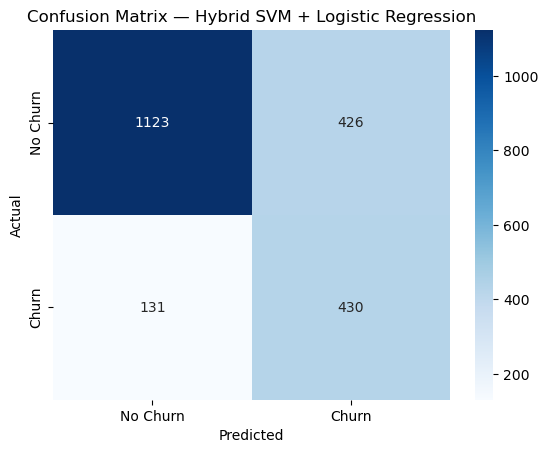

In [22]:
# Confusion Matrix — Hybrid SVM + LR
cm_svm_lr = confusion_matrix(y_test, hybrid_svm_lr_predictions)
sns.heatmap(cm_svm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix — Hybrid SVM + Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [23]:
# Metrics — Hybrid SVM + LR
print("=== Hybrid SVM + Logistic Regression Metrics ===")
print("Precision :", round(precision_score(y_test, hybrid_svm_lr_predictions), 2))
print("Recall    :", round(recall_score(y_test, hybrid_svm_lr_predictions), 2))
print("F1 Score  :", round(f1_score(y_test, hybrid_svm_lr_predictions), 2))
svm_lr_fpr, svm_lr_tpr, _ = roc_curve(y_test, hybrid_svm_lr_proba)
svm_lr_auc = round(auc(svm_lr_fpr, svm_lr_tpr), 2)
print("AUC       :", svm_lr_auc)

=== Hybrid SVM + Logistic Regression Metrics ===
Precision : 0.5
Recall    : 0.77
F1 Score  : 0.61
AUC       : 0.82


In [24]:
# Hybrid 2 — SVM + XGBoost
# SVM handles complex boundaries, XGBoost handles imbalanced data well
hybrid_svm_xgb = VotingClassifier(
    estimators=[
        ("svm", SVC(probability=True, random_state=42)),
        ("xgb", XGBClassifier(random_state=42, eval_metric="logloss"))
    ],
    voting="soft"
)

hybrid_svm_xgb.fit(X_train_balanced, y_train_balanced)
hybrid_svm_xgb_predictions = hybrid_svm_xgb.predict(X_test)
hybrid_svm_xgb_proba = hybrid_svm_xgb.predict_proba(X_test)[:, 1]

print("=== Hybrid — SVM + XGBoost ===")
print(classification_report(y_test, hybrid_svm_xgb_predictions, target_names=["No Churn", "Churn"]))

=== Hybrid — SVM + XGBoost ===
              precision    recall  f1-score   support

    No Churn       0.89      0.73      0.80      1549
       Churn       0.50      0.75      0.60       561

    accuracy                           0.73      2110
   macro avg       0.69      0.74      0.70      2110
weighted avg       0.79      0.73      0.75      2110



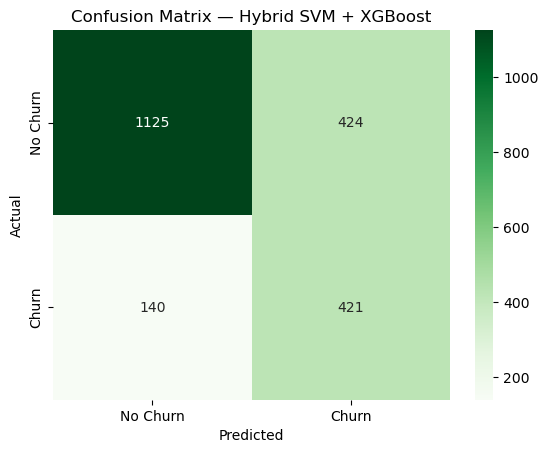

In [25]:
# Confusion Matrix — Hybrid SVM + XGBoost
cm_svm_xgb = confusion_matrix(y_test, hybrid_svm_xgb_predictions)
sns.heatmap(cm_svm_xgb, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix — Hybrid SVM + XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [26]:
# Metrics — Hybrid SVM + XGBoost
print("=== Hybrid SVM + XGBoost Metrics ===")
print("Precision :", round(precision_score(y_test, hybrid_svm_xgb_predictions), 2))
print("Recall    :", round(recall_score(y_test, hybrid_svm_xgb_predictions), 2))
print("F1 Score  :", round(f1_score(y_test, hybrid_svm_xgb_predictions), 2))
svm_xgb_fpr, svm_xgb_tpr, _ = roc_curve(y_test, hybrid_svm_xgb_proba)
svm_xgb_auc = round(auc(svm_xgb_fpr, svm_xgb_tpr), 2)
print("AUC       :", svm_xgb_auc)

=== Hybrid SVM + XGBoost Metrics ===
Precision : 0.5
Recall    : 0.75
F1 Score  : 0.6
AUC       : 0.81


In [27]:
# Hybrid 3 — Logistic Regression + XGBoost
# LR provides simple linear patterns, XGBoost provides complex non-linear patterns
hybrid_lr_xgb = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(random_state=42)),
        ("xgb", XGBClassifier(random_state=42, eval_metric="logloss"))
    ],
    voting="soft"
)

hybrid_lr_xgb.fit(X_train_balanced, y_train_balanced)
hybrid_lr_xgb_predictions = hybrid_lr_xgb.predict(X_test)
hybrid_lr_xgb_proba = hybrid_lr_xgb.predict_proba(X_test)[:, 1]

print("=== Hybrid — Logistic Regression + XGBoost ===")
print(classification_report(y_test, hybrid_lr_xgb_predictions, target_names=["No Churn", "Churn"]))

=== Hybrid — Logistic Regression + XGBoost ===
              precision    recall  f1-score   support

    No Churn       0.90      0.71      0.79      1549
       Churn       0.49      0.77      0.60       561

    accuracy                           0.73      2110
   macro avg       0.69      0.74      0.69      2110
weighted avg       0.79      0.73      0.74      2110



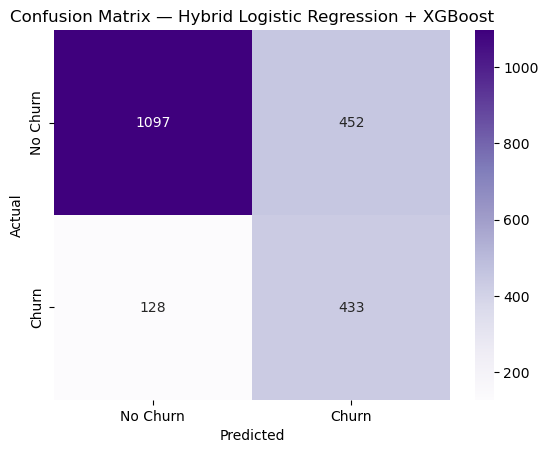

In [28]:
# Confusion Matrix — Hybrid LR + XGBoost
cm_lr_xgb = confusion_matrix(y_test, hybrid_lr_xgb_predictions)
sns.heatmap(cm_lr_xgb, annot=True, fmt="d", cmap="Purples",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix — Hybrid Logistic Regression + XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [29]:
# Metrics — Hybrid LR + XGBoost
print("=== Hybrid Logistic Regression + XGBoost Metrics ===")
print("Precision :", round(precision_score(y_test, hybrid_lr_xgb_predictions), 2))
print("Recall    :", round(recall_score(y_test, hybrid_lr_xgb_predictions), 2))
print("F1 Score  :", round(f1_score(y_test, hybrid_lr_xgb_predictions), 2))
lr_xgb_fpr, lr_xgb_tpr, _ = roc_curve(y_test, hybrid_lr_xgb_proba)
lr_xgb_auc = round(auc(lr_xgb_fpr, lr_xgb_tpr), 2)
print("AUC       :", lr_xgb_auc)

=== Hybrid Logistic Regression + XGBoost Metrics ===
Precision : 0.49
Recall    : 0.77
F1 Score  : 0.6
AUC       : 0.82


In [30]:
# Hybrid 4 — All Three Combined: SVM + Logistic Regression + XGBoost
hybrid_all = VotingClassifier(
    estimators=[
        ("svm", SVC(probability=True, random_state=42)),
        ("lr", LogisticRegression(random_state=42)),
        ("xgb", XGBClassifier(random_state=42, eval_metric="logloss"))
    ],
    voting="soft"
)

hybrid_all.fit(X_train_balanced, y_train_balanced)
hybrid_all_predictions = hybrid_all.predict(X_test)
hybrid_all_proba = hybrid_all.predict_proba(X_test)[:, 1]

print("=== Hybrid — SVM + Logistic Regression + XGBoost ===")
print(classification_report(y_test, hybrid_all_predictions, target_names=["No Churn", "Churn"]))

=== Hybrid — SVM + Logistic Regression + XGBoost ===
              precision    recall  f1-score   support

    No Churn       0.89      0.74      0.81      1549
       Churn       0.51      0.75      0.60       561

    accuracy                           0.74      2110
   macro avg       0.70      0.74      0.70      2110
weighted avg       0.79      0.74      0.75      2110



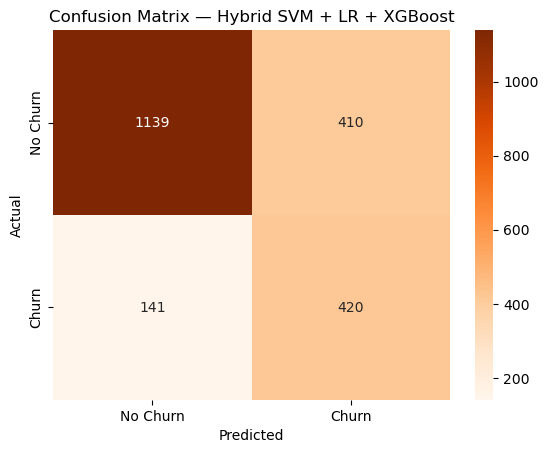

In [31]:
# Confusion Matrix — All Three Hybrid
cm_all = confusion_matrix(y_test, hybrid_all_predictions)
sns.heatmap(cm_all, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix — Hybrid SVM + LR + XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [32]:
# Metrics — All Three Hybrid
print("=== Hybrid SVM + LR + XGBoost Metrics ===")
print("Precision :", round(precision_score(y_test, hybrid_all_predictions), 2))
print("Recall    :", round(recall_score(y_test, hybrid_all_predictions), 2))
print("F1 Score  :", round(f1_score(y_test, hybrid_all_predictions), 2))
all_fpr, all_tpr, _ = roc_curve(y_test, hybrid_all_proba)
all_auc = round(auc(all_fpr, all_tpr), 2)
print("AUC       :", all_auc)

=== Hybrid SVM + LR + XGBoost Metrics ===
Precision : 0.51
Recall    : 0.75
F1 Score  : 0.6
AUC       : 0.82


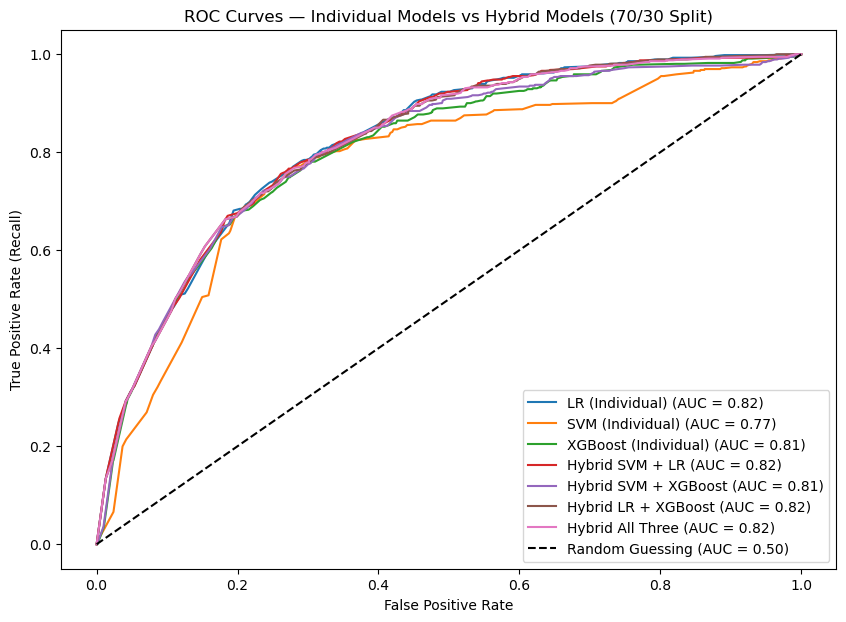

In [33]:
# ROC Curves — Individual vs Hybrid models on one chart
plt.figure(figsize=(10, 7))

for name, fpr, tpr, auc_score in [
    ("LR (Individual)", lr_fpr, lr_tpr, lr_auc),
    ("SVM (Individual)", svm_fpr, svm_tpr, svm_auc),
    ("XGBoost (Individual)", xgb_fpr, xgb_tpr, xgb_auc),
    ("Hybrid SVM + LR", svm_lr_fpr, svm_lr_tpr, svm_lr_auc),
    ("Hybrid SVM + XGBoost", svm_xgb_fpr, svm_xgb_tpr, svm_xgb_auc),
    ("Hybrid LR + XGBoost", lr_xgb_fpr, lr_xgb_tpr, lr_xgb_auc),
    ("Hybrid All Three", all_fpr, all_tpr, all_auc)
]:
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score})")

plt.plot([0, 1], [0, 1], "k--", label="Random Guessing (AUC = 0.50)")
plt.title("ROC Curves — Individual Models vs Hybrid Models (70/30 Split)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.legend(loc="lower right")
plt.show()

In [34]:
# Final comparison — all models side by side
comparison = pd.DataFrame({
    "Model": [
        "LR (Individual)",
        "SVM (Individual)",
        "XGBoost (Individual)",
        "Hybrid SVM + LR",
        "Hybrid SVM + XGBoost",
        "Hybrid LR + XGBoost",
        "Hybrid All Three"
    ],
    "Precision": [
        round(precision_score(y_test, lr_predictions), 2),
        round(precision_score(y_test, svm_predictions), 2),
        round(precision_score(y_test, xgb_predictions), 2),
        round(precision_score(y_test, hybrid_svm_lr_predictions), 2),
        round(precision_score(y_test, hybrid_svm_xgb_predictions), 2),
        round(precision_score(y_test, hybrid_lr_xgb_predictions), 2),
        round(precision_score(y_test, hybrid_all_predictions), 2)
    ],
    "Recall": [
        round(recall_score(y_test, lr_predictions), 2),
        round(recall_score(y_test, svm_predictions), 2),
        round(recall_score(y_test, xgb_predictions), 2),
        round(recall_score(y_test, hybrid_svm_lr_predictions), 2),
        round(recall_score(y_test, hybrid_svm_xgb_predictions), 2),
        round(recall_score(y_test, hybrid_lr_xgb_predictions), 2),
        round(recall_score(y_test, hybrid_all_predictions), 2)
    ],
    "F1 Score": [
        round(f1_score(y_test, lr_predictions), 2),
        round(f1_score(y_test, svm_predictions), 2),
        round(f1_score(y_test, xgb_predictions), 2),
        round(f1_score(y_test, hybrid_svm_lr_predictions), 2),
        round(f1_score(y_test, hybrid_svm_xgb_predictions), 2),
        round(f1_score(y_test, hybrid_lr_xgb_predictions), 2),
        round(f1_score(y_test, hybrid_all_predictions), 2)
    ],
    "AUC": [
        lr_auc, svm_auc, xgb_auc,
        svm_lr_auc, svm_xgb_auc, lr_xgb_auc, all_auc
    ]
})

print(comparison.to_string(index=False))

               Model  Precision  Recall  F1 Score  AUC
     LR (Individual)       0.49    0.78      0.60 0.82
    SVM (Individual)       0.50    0.76      0.60 0.77
XGBoost (Individual)       0.50    0.75      0.60 0.81
     Hybrid SVM + LR       0.50    0.77      0.61 0.82
Hybrid SVM + XGBoost       0.50    0.75      0.60 0.81
 Hybrid LR + XGBoost       0.49    0.77      0.60 0.82
    Hybrid All Three       0.51    0.75      0.60 0.82


In [35]:
# Save the best model based on highest AUC from comparison table above
import pickle

best_auc = max(lr_auc, svm_auc, xgb_auc,
               svm_lr_auc, svm_xgb_auc, lr_xgb_auc, all_auc)

print("Best AUC:", best_auc)

if best_auc == all_auc:
    best_model = hybrid_all
    print("Best Model: Hybrid All Three")
elif best_auc == svm_lr_auc:
    best_model = hybrid_svm_lr
    print("Best Model: Hybrid SVM + LR")
elif best_auc == svm_xgb_auc:
    best_model = hybrid_svm_xgb
    print("Best Model: Hybrid SVM + XGBoost")
elif best_auc == lr_xgb_auc:
    best_model = hybrid_lr_xgb
    print("Best Model: Hybrid LR + XGBoost")
elif best_auc == xgb_auc:
    best_model = xgb_model
    print("Best Model: XGBoost (Individual)")
elif best_auc == svm_auc:
    best_model = svm_model
    print("Best Model: SVM (Individual)")
else:
    best_model = lr_model
    print("Best Model: Logistic Regression (Individual)")

with open("/home/ae7ba225-76ef-4005-aee2-7847a70630ed/SilentTelecomChurn/churn_model_7030.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Best model saved as churn_model_7030.pkl")

Best AUC: 0.82
Best Model: Hybrid All Three
Best model saved as churn_model_7030.pkl
